In [3]:
# If you're in Jupyter, force a stable inline backend first (run this once per session)
%matplotlib inline

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

path = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

img = tiff.imread(path)  # uint16, (256, 320)
arr = img.astype(np.float32)  # safer for normalization
# Basic info
print(f"Shape: {arr.shape}")
print(f"Data type: {arr.dtype}")

# Core statistics
print(f"Min: {arr.min():.2f}")
print(f"Max: {arr.max():.2f}")
print(f"Mean: {arr.mean():.2f}")
print(f"Median: {np.median(arr):.2f}")
print(f"Standard deviation: {arr.std():.2f}")

# Optional percentiles
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"{p}th percentile: {np.percentile(arr, p):.2f}")

# Count of unique values (for diagnostics)
print(f"Unique values: {len(np.unique(arr))}")


Shape: (256, 320)
Data type: float32
Min: 0.00
Max: 65535.00
Mean: 7913.33
Median: 7942.00
Standard deviation: 3217.16
1th percentile: 0.00
5th percentile: 6835.00
25th percentile: 7520.00
50th percentile: 7942.00
75th percentile: 8330.00
95th percentile: 8833.00
99th percentile: 9117.00
Unique values: 3695


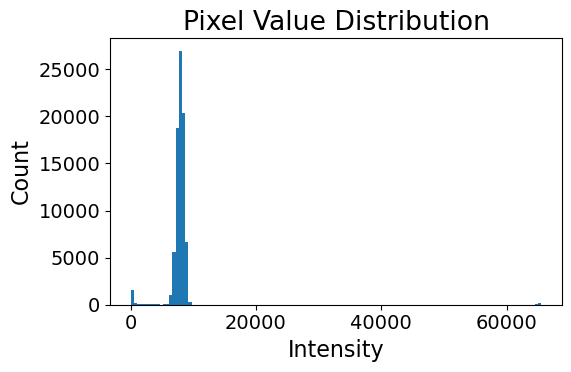

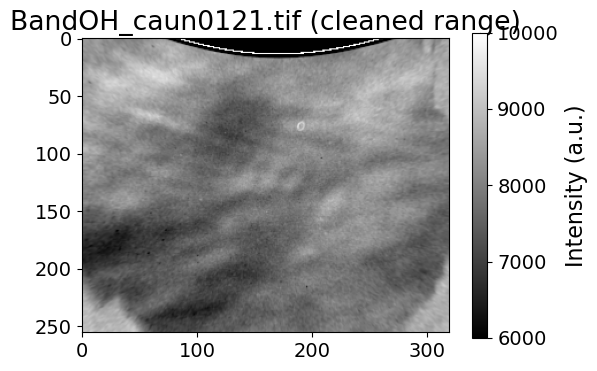

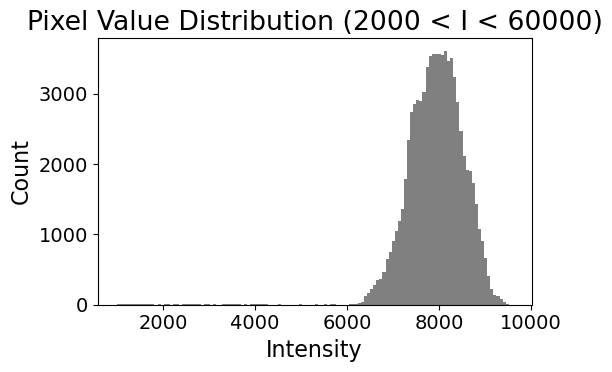

In [52]:
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

img = tiff.imread(path)  # uint16, (256, 320)
arr = img.astype(np.float32)  # safer for normalization

# Histogram
sample = arr.ravel()

plt.figure(figsize=(6,4))
plt.hist(sample, bins=128)
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title("Pixel Value Distribution")
plt.tight_layout()
plt.show()
plt.close()

# Plot
plt.figure(figsize=(6, 4))
plt.imshow(np.clip(arr, 6000, 10000), cmap="gray")
plt.colorbar(label="Intensity (a.u.)")
plt.title("BandOH_caun0121.tif (cleaned range)")
plt.tight_layout()
plt.show()
plt.close()

# Histogram of cleaned data
sample = arr_clipped.ravel()

plt.figure(figsize=(6, 4))
plt.hist(sample, bins=128, color='gray')
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title("Pixel Value Distribution (2000 < I < 60000)")
plt.tight_layout()
plt.show()
plt.close()



In-range count: 61759
Min/Max: 6001.00 / 9581.00
Mean/Std: 8027.31 / 527.89
Percentiles 5/50/95: 7128.00 / 8074.00 / 8847.00
------------
cluster= 0
amplitude= 0.3511157754956873 idx= (np.int64(1), np.int64(11), np.int64(63), np.int64(65))
selected elements: 349569
------------
cluster= 1
amplitude= 0.34545491525187866 idx= (np.int64(9), np.int64(8), np.int64(66), np.int64(137))
selected elements: 1457335
------------
cluster= 2
amplitude= 0.3379224004298002 idx= (np.int64(5), np.int64(7), np.int64(248), np.int64(134))
selected elements: 279763
------------
cluster= 3
amplitude= 0.3270376184797193 idx= (np.int64(2), np.int64(7), np.int64(114), np.int64(179))
selected elements: 19978
------------
cluster= 4
amplitude= 0.32455574110829505 idx= (np.int64(10), np.int64(9), np.int64(70), np.int64(101))
selected elements: 61245
------------
cluster= 5
amplitude= 0.32363534376392955 idx= (np.int64(3), np.int64(8), np.int64(145), np.int64(144))
selected elements: 76871
------------
cluster= 6


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 85.26it/s]


Wave 0: peak amp = 0.351+0.000j, lamx=-34.8, lamy=12.7, lam=11.9
Wave 1: peak amp = 0.345+0.000j, lamx=273.9, lamy=48.3, lam=47.6


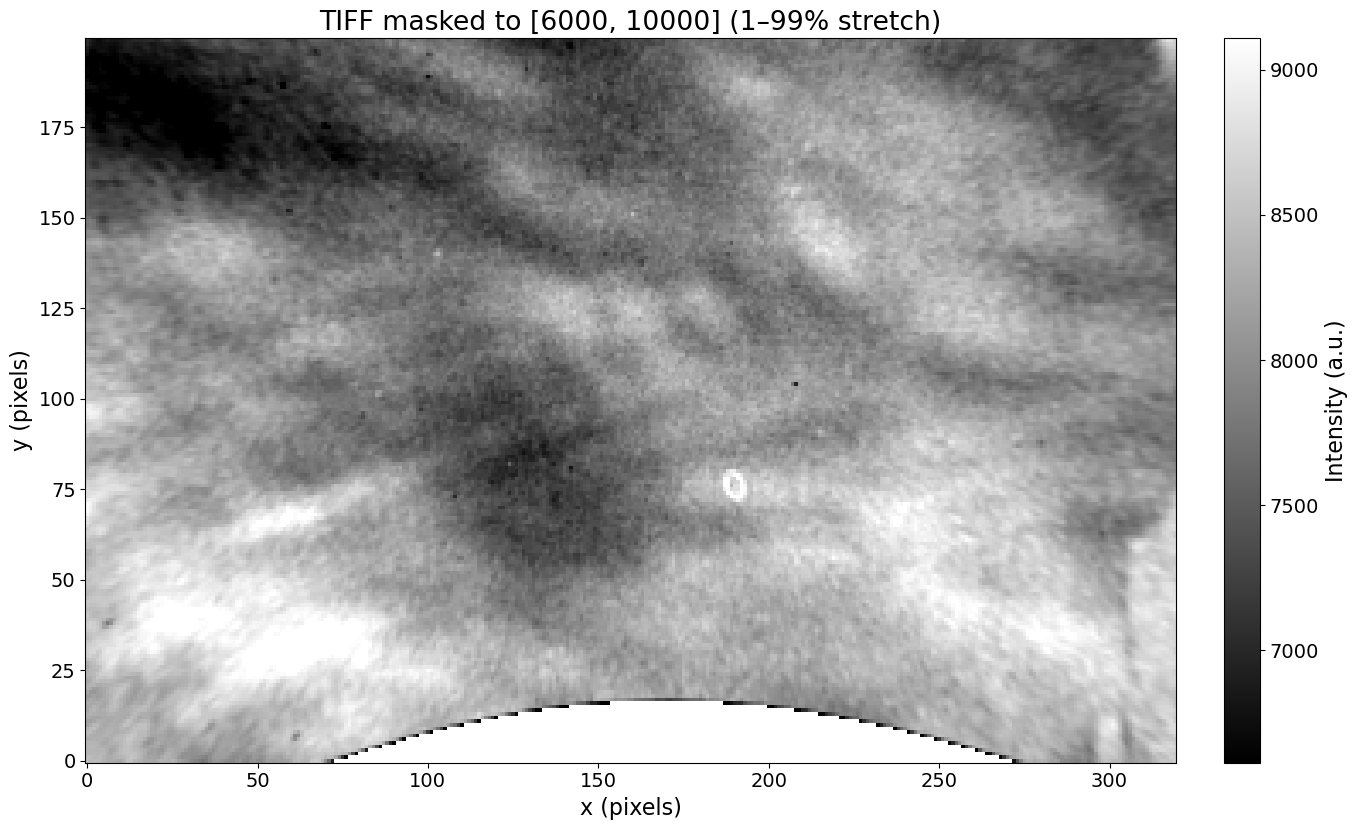

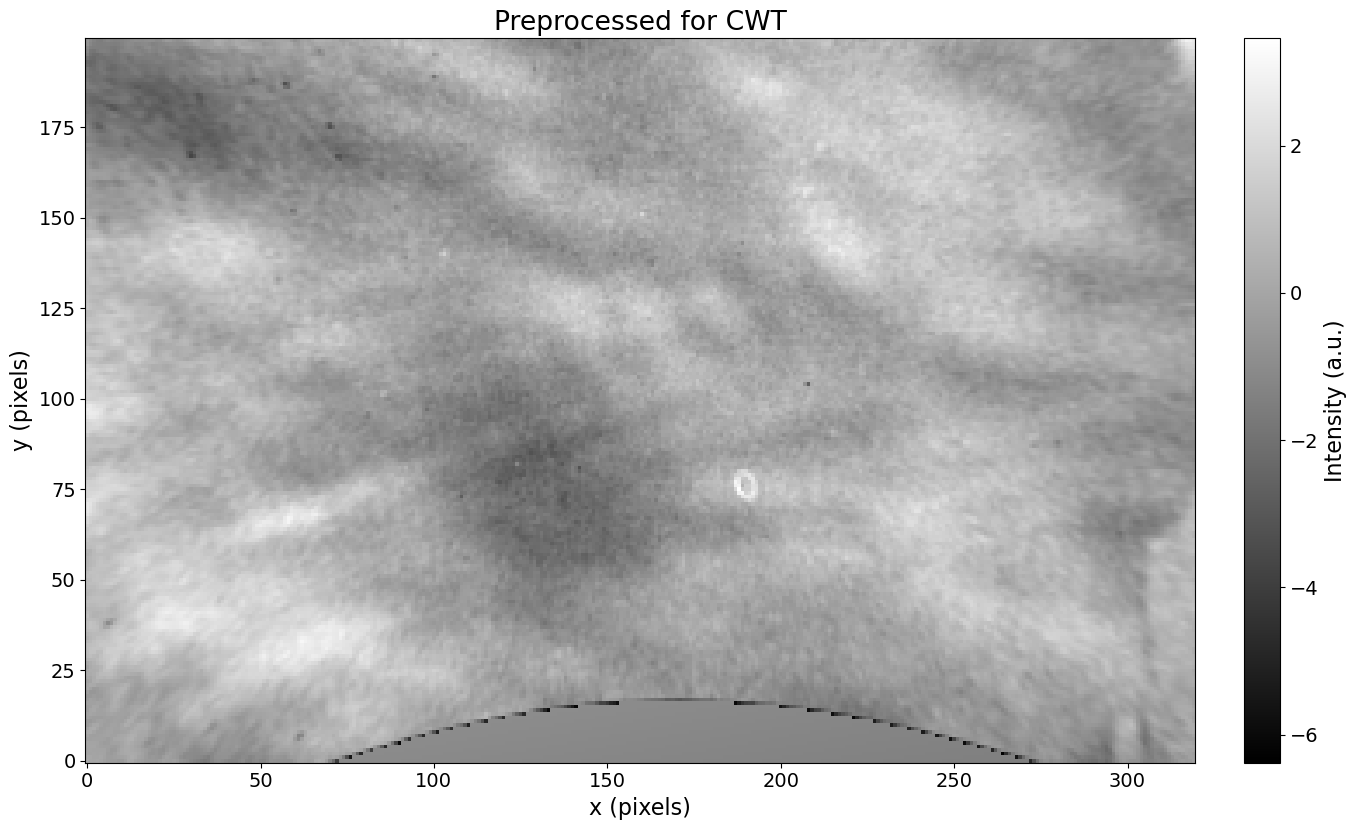

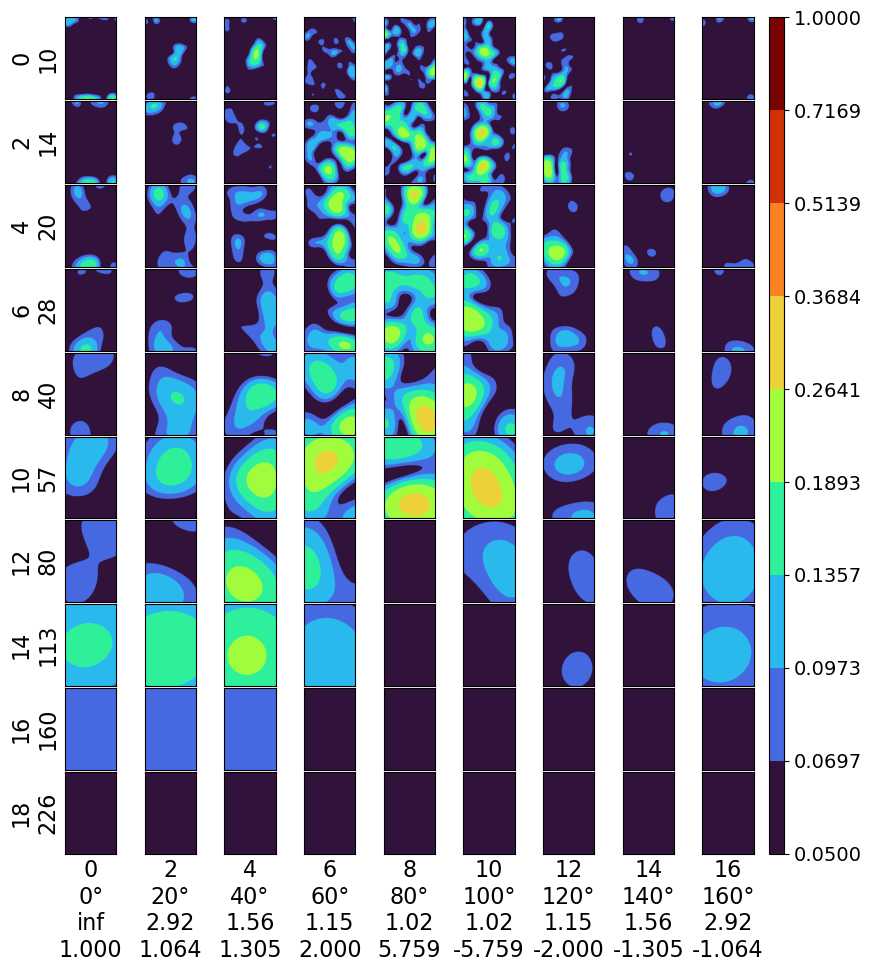

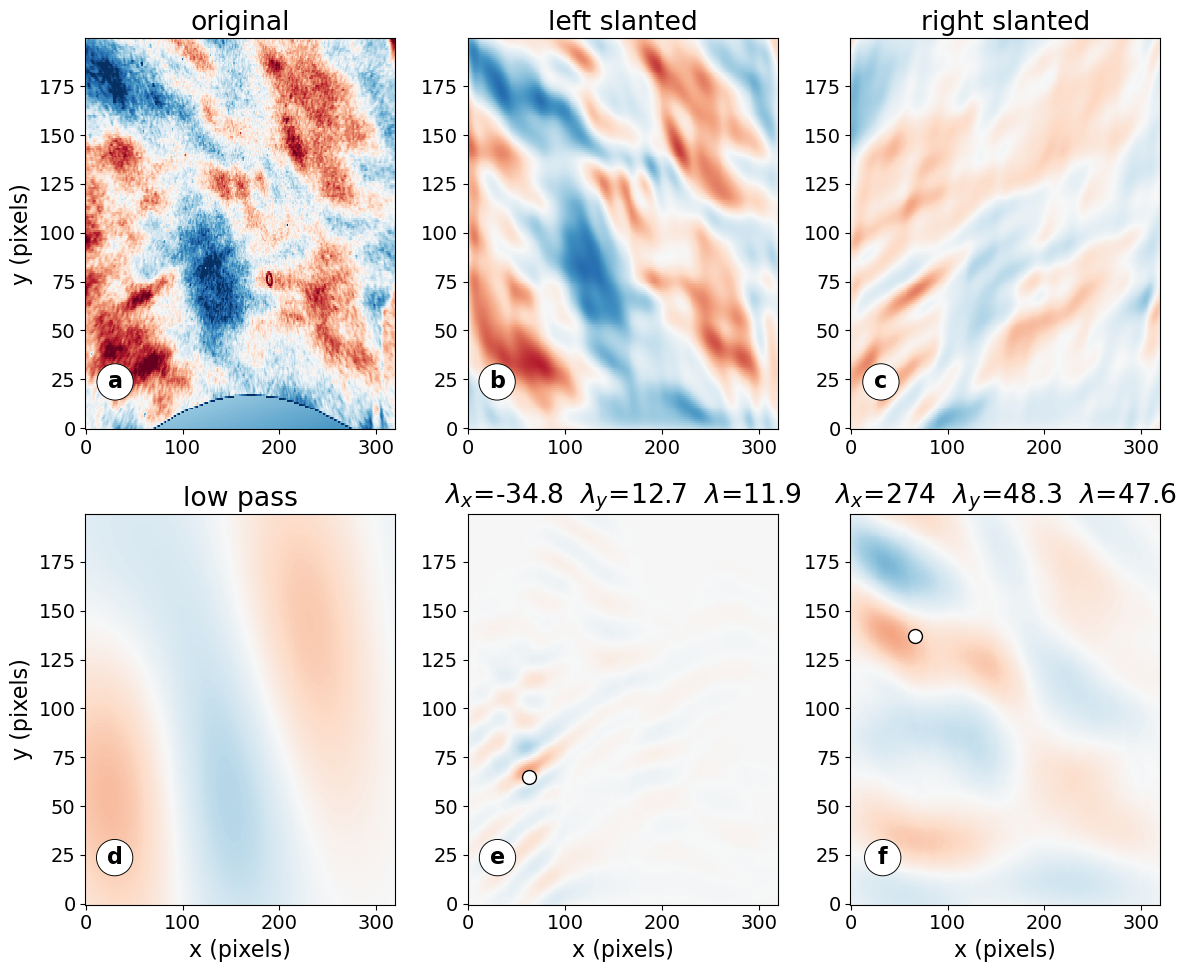

In [56]:
# example_decompose2d_from_tiff_rangefilter.py
# Load a 16-bit TIFF, remove values outside [6000, 10000] for stats/preview,
# fill them for CWT, then run juwavelet 2D CWT and show components.

from __future__ import annotations
import string
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = None
Y_SLICE: Optional[slice] = slice(0, 200)

# Range filter (remove everything <min or >max for stats/preview)
APPLY_RANGE_FILTER = True
RANGE_MIN = 6000.0
RANGE_MAX = 10000.0

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing
REMOVE_TREND = True        # subtract 2D plane
STANDARDIZE = True         # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0     # 0 disables, else e.g. 0.8

# Wavelet params
S0 = 10
DJ = 1/8
JS = 20
JT = 18
ASPECT = 1

# Pixel spacing
DX = .623
DY = .623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win

def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)

def detrend_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return Z - plane

def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))

def quicklook_pcolor(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str, cmap="gray") -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()

def robust_stretch(Z: np.ndarray, p1=1, p2=99) -> np.ndarray:
    v1, v2 = np.percentile(Z[np.isfinite(Z)], [p1, p2])
    return np.clip(Z, v1, v2)

def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[valid_mask])) if np.any(valid_mask) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[valid_mask])) if np.any(valid_mask) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)

    # Range filter: create masked preview and stats
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, RANGE_MIN, RANGE_MAX)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan  # remove for stats/preview

        # Quick stats on in-range values only
        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"Min/Max: {np.nanmin(preview):.2f} / {np.nanmax(preview):.2f}")
            print(f"Mean/Std: {np.nanmean(preview):.2f} / {np.nanstd(preview):.2f}")
            print(f"Percentiles 5/50/95: {np.nanpercentile(preview, 5):.2f} / "
                  f"{np.nanpercentile(preview, 50):.2f} / {np.nanpercentile(preview, 95):.2f}")
        else:
            print("Warning: no pixels within the specified range")

        # Show masked quicklook with robust stretch over valid data
        stretched = preview.copy()
        finite = np.isfinite(stretched)
        if np.any(finite):
            v1, v2 = np.nanpercentile(stretched, [1, 99])
            stretched = np.clip(stretched, v1, v2)
        quicklook_pcolor(x1d, y1d, stretched, f"TIFF masked to [{RANGE_MIN:.0f}, {RANGE_MAX:.0f}] (1–99% stretch)")
    else:
        # No range filtering
        vals = raw.ravel()
        print(f"All-pixel stats — min {raw.min():.2f}, max {raw.max():.2f}, mean {raw.mean():.2f}, std {raw.std():.2f}")
        quicklook_pcolor(x1d, y1d, robust_stretch(raw), "TIFF raw (1–99% stretch)")

    # Prepare data for CWT: fill removed pixels to keep rectangular grid
    if APPLY_RANGE_FILTER:
        filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT)
    else:
        filled = raw

    # Preprocess for CWT
    proc = filled.copy()
    if REMOVE_TREND:
        proc = detrend_plane(proc)
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        proc = (proc - m) / s if s > 0 else (proc - m)
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    quicklook_pcolor(x1d, y1d, proc, "Preprocessed for CWT")

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.1)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # Component panels
    fig2, axs = plt.subplots(2, 3, figsize=(12, 10))
    axs = axs.T  # (3, 2)
    opts = {"cmap": "RdBu_r", "vmin": -2.5, "vmax": 2.5, "rasterized": True}

    # original
    axs[0, 0].set_title("original")
    axs[0, 0].pcolormesh(x1d, y1d, proc, **opts)

    # left slanted
    decomposition[:] = orig
    decomposition[:, (np.pi / 2 < theta)] = 0
    rec = transform.reconstruct2d(cwt)  # (nx, ny)
    axs[1, 0].set_title("left slanted")
    axs[1, 0].pcolormesh(x1d, y1d, rec.T, **opts)

    # right slanted
    decomposition[:] = orig
    decomposition[:, (theta <= np.pi / 2)] = 0
    rec = transform.reconstruct2d(cwt)
    axs[2, 0].set_title("right slanted")
    axs[2, 0].pcolormesh(x1d, y1d, rec.T, **opts)

    # low pass (period >= 100 kept)
    decomposition[:] = orig
    decomposition[period < 100] = 0
    rec = transform.reconstruct2d(cwt)
    axs[0, 1].set_title("low pass")
    axs[0, 1].pcolormesh(x1d, y1d, rec.T, **opts)

    # highlight two identified waves (if present)
    demo_indices = [0, 1]
    targets = [(1, axs[1, 1]), (2, axs[2, 1])]

    def _fmt(v):
        if not np.isfinite(v):
            return "∞"
        v = float(v)
        if abs(v) >= 1000 or abs(v) < 0.1:
            return f"{v:.2e}"
        elif abs(v) >= 100:
            return f"{v:.0f}"
        else:
            return f"{v:.1f}"

    for (demo_idx, (rowi, ax)) in zip(demo_indices, targets):
        if isinstance(idxs, (list, tuple)) and demo_idx < len(idxs):
            decomposition[:] = orig
            decomposition[iwave != demo_idx] = 0
            udx = idxs[demo_idx]  # (scale_index, angle_index)

            rec = transform.reconstruct2d(cwt)

            lamx = cwt["wavelength_x"][udx[0], udx[1]]
            lamy = cwt["wavelength_y"][udx[0], udx[1]]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                rf"$\lambda_x$={_fmt(lamx)}  "
                rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d, y1d, rec.T, **opts)

            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[udx[0], udx[1]].argmax(), decomposition[0, 0].shape
            )
            ax.plot(x1d[max_idx[0]], y1d[max_idx[1]], "o", color="w", mec="k", ms=10)
            print(
                f"Wave {demo_idx}: peak amp = {decomposition[udx[0], udx[1]].max():.3f}, "
                f"lamx={lamx:.1f}, lamy={lamy:.1f}, lam={'inf' if not np.isfinite(lam) else f'{lam:.1f}'}"
            )
        else:
            ax.set_title(f"wave {demo_idx} not found")
            ax.axis("off")

    # labels
    for ax in axs[:, 1]:
        ax.set_xlabel("x (pixels)")
    for ax in axs[0, :]:
        ax.set_ylabel("y (pixels)")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs.T.reshape(-1), string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)

# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


## 5 Biggest Waves
    Wavelet params
    S0 = 10
    DJ = 1/8
    JS = 20
    JT = 36
    ASPECT = 1

    min_amp=0.25 
    thr=0.15

## 5 Biggest Waves
    Wavelet params
    S0 = 10
    DJ = 1/8
    JS = 20
    JT = 36
    ASPECT = 1

    min_amp=0.25 
    thr=0.15

In-range count: 61759
Min/Max: 6001.00 / 9581.00
Mean/Std: 8027.31 / 527.89
Percentiles 5/50/95: 7128.00 / 8074.00 / 8847.00
------------
cluster= 0
amplitude= 0.3700673060130071 idx= (np.int64(2), np.int64(21), np.int64(62), np.int64(65))
selected elements: 334232
------------
cluster= 1
amplitude= 0.3480638925173568 idx= (np.int64(9), np.int64(14), np.int64(252), np.int64(126))
selected elements: 504112
------------
cluster= 2
amplitude= 0.34545491525187866 idx= (np.int64(18), np.int64(16), np.int64(66), np.int64(137))
selected elements: 1537338
------------
cluster= 3
amplitude= 0.3311564261412558 idx= (np.int64(6), np.int64(14), np.int64(129), np.int64(152))
selected elements: 289336
------------
cluster= 4
amplitude= 0.3216293088512097 idx= (np.int64(3), np.int64(19), np.int64(193), np.int64(72))
selected elements: 110397
------------
cluster= 5
amplitude= 0.3064298969649246 idx= (np.int64(3), np.int64(15), np.int64(108), np.int64(186))
selected elements: 35506
------------
cluste

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 28.84it/s]


Top wave 1 (idx=0): amp=0.370, lamx=-45.95, lamy=12.31, lam=11.89
Top wave 2 (idx=1): amp=0.348, lamx=63.77, lamy=23.21, lam=21.81
Top wave 3 (idx=2): amp=0.345, lamx=273.93, lamy=48.30, lam=47.57
Top wave 4 (idx=3): amp=0.331, lamx=49.17, lamy=17.90, lam=16.82
Top wave 5 (idx=4): amp=0.322, lamx=-148.80, lamy=13.02, lam=12.97


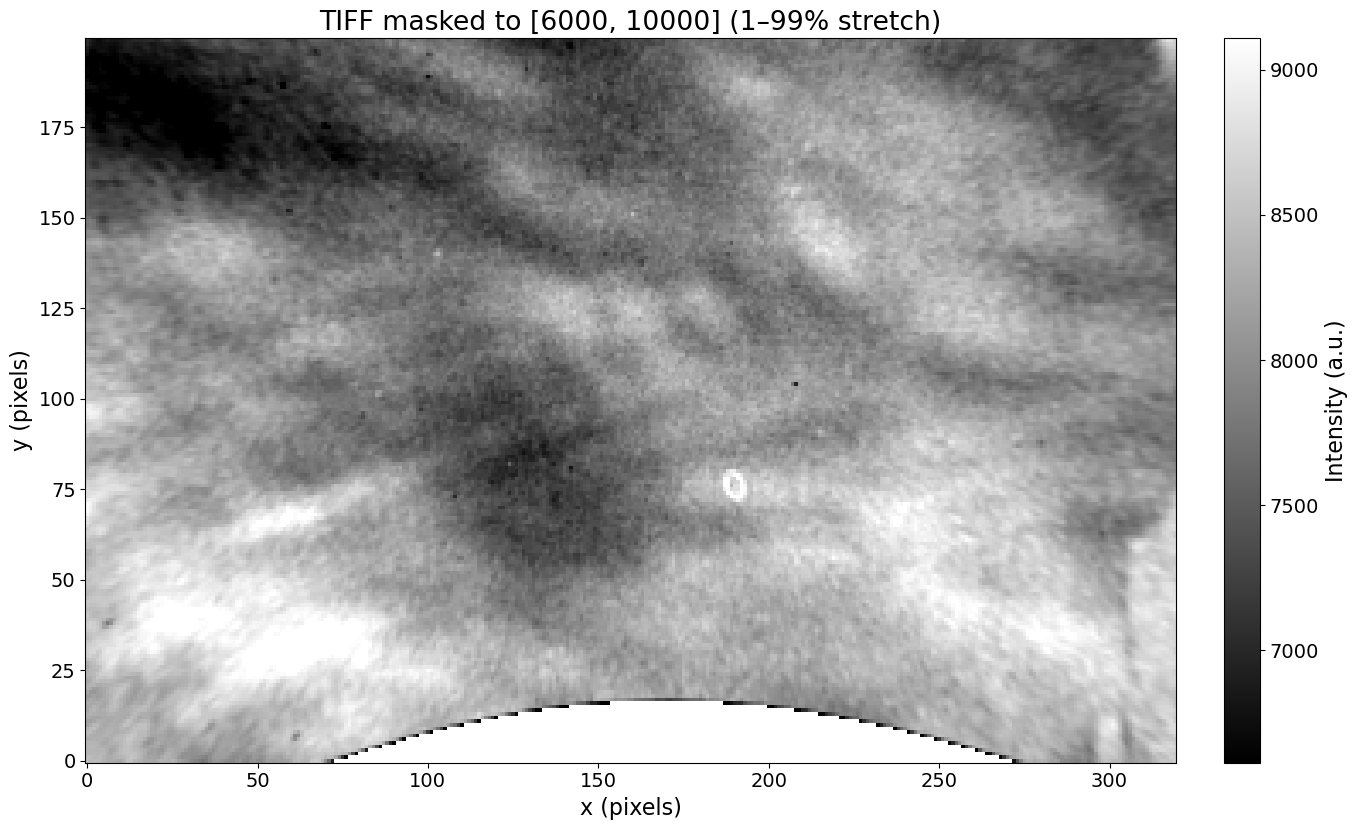

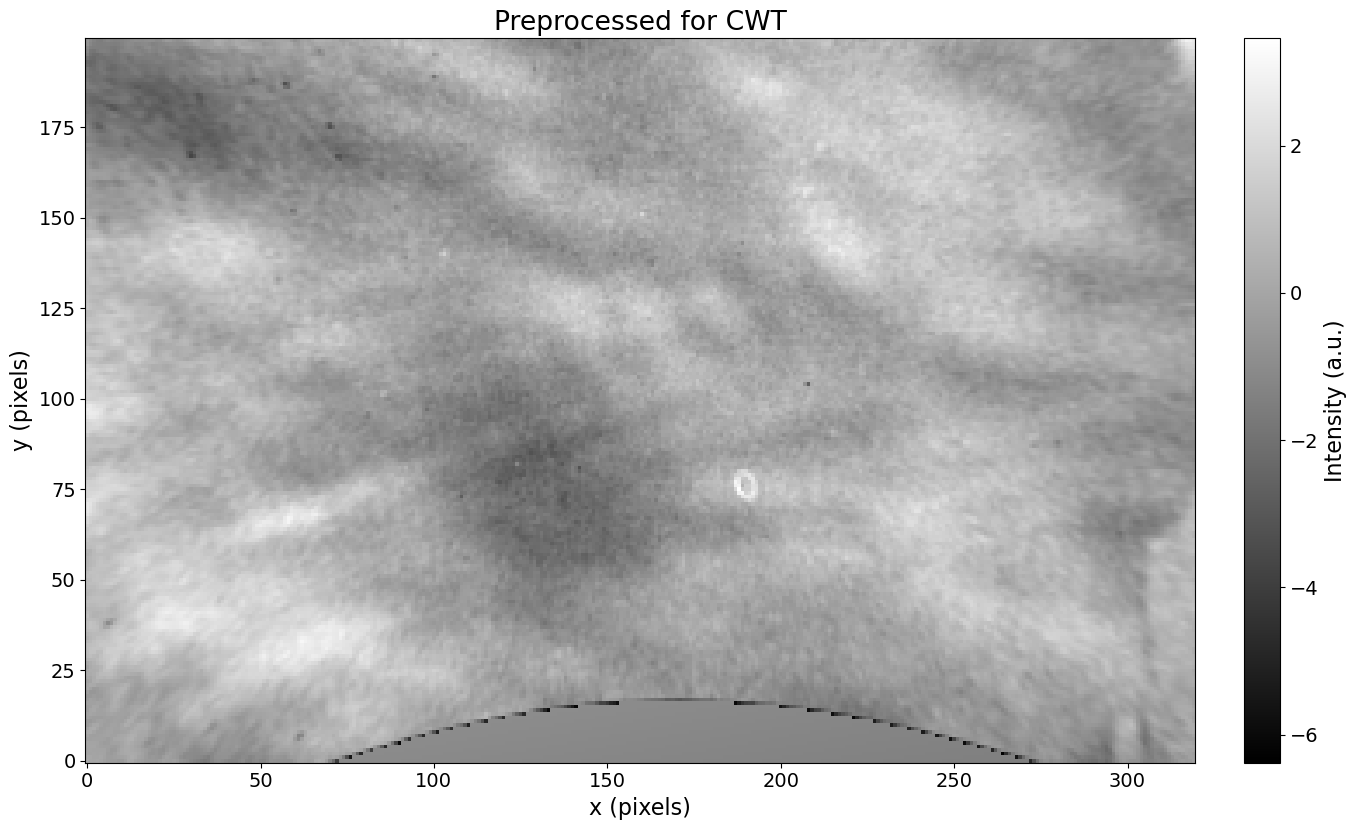

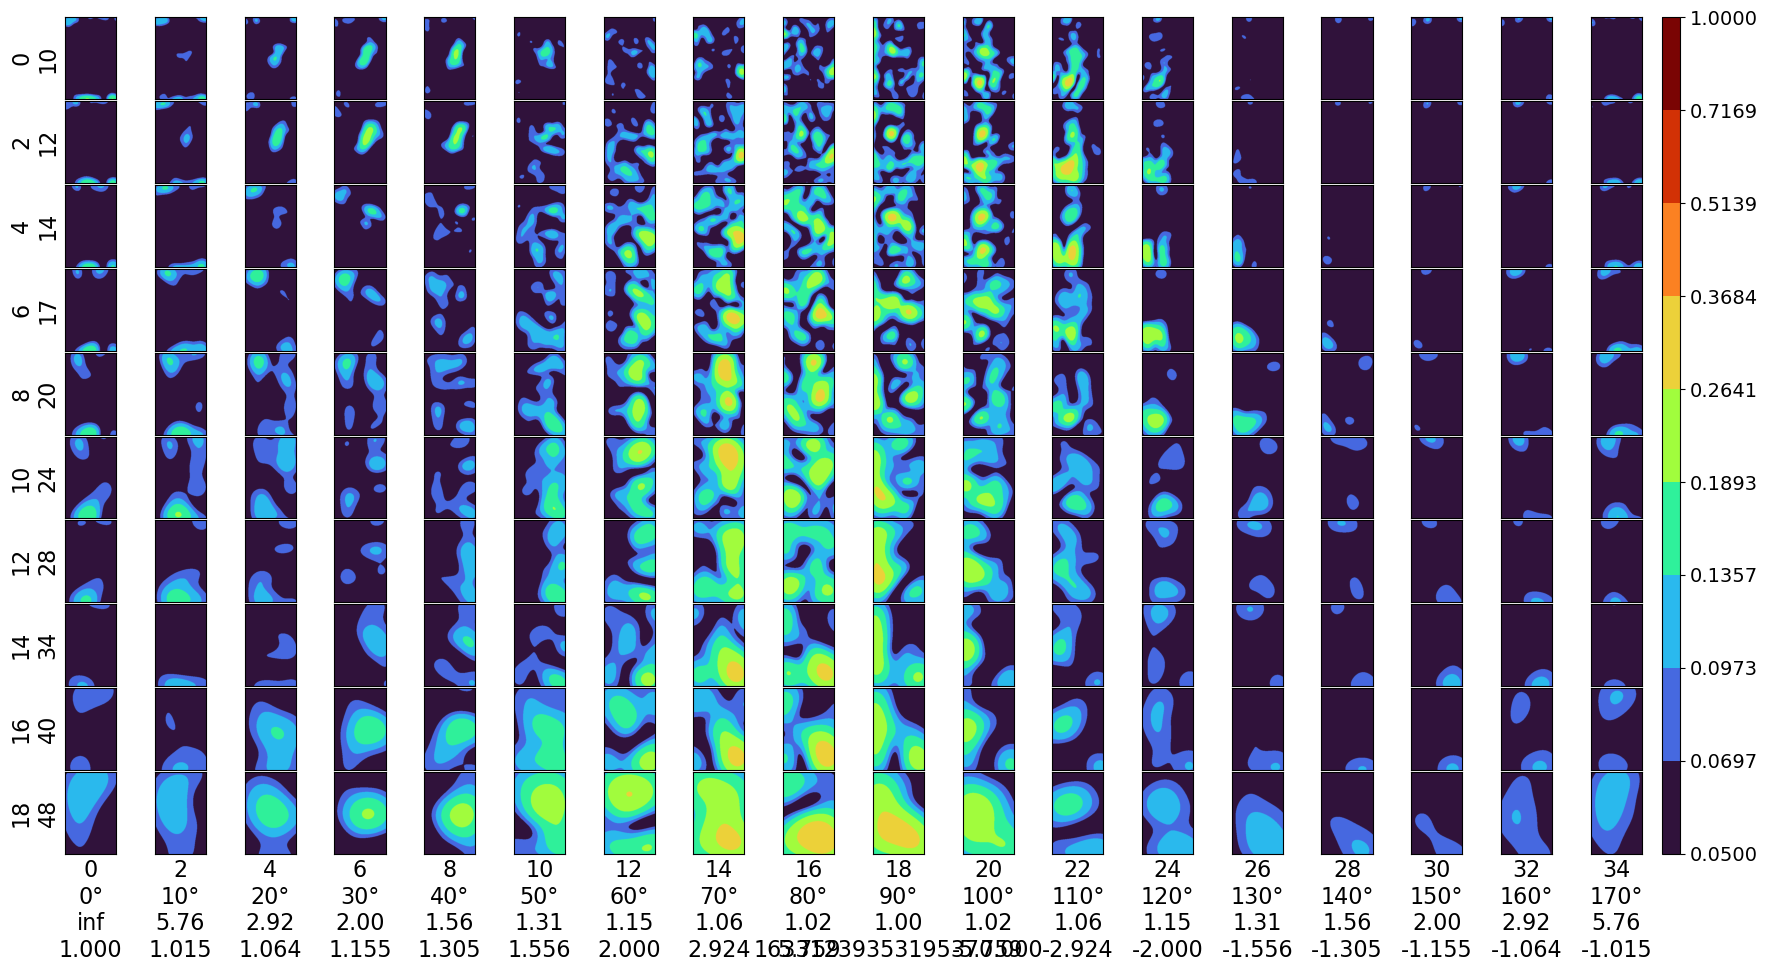

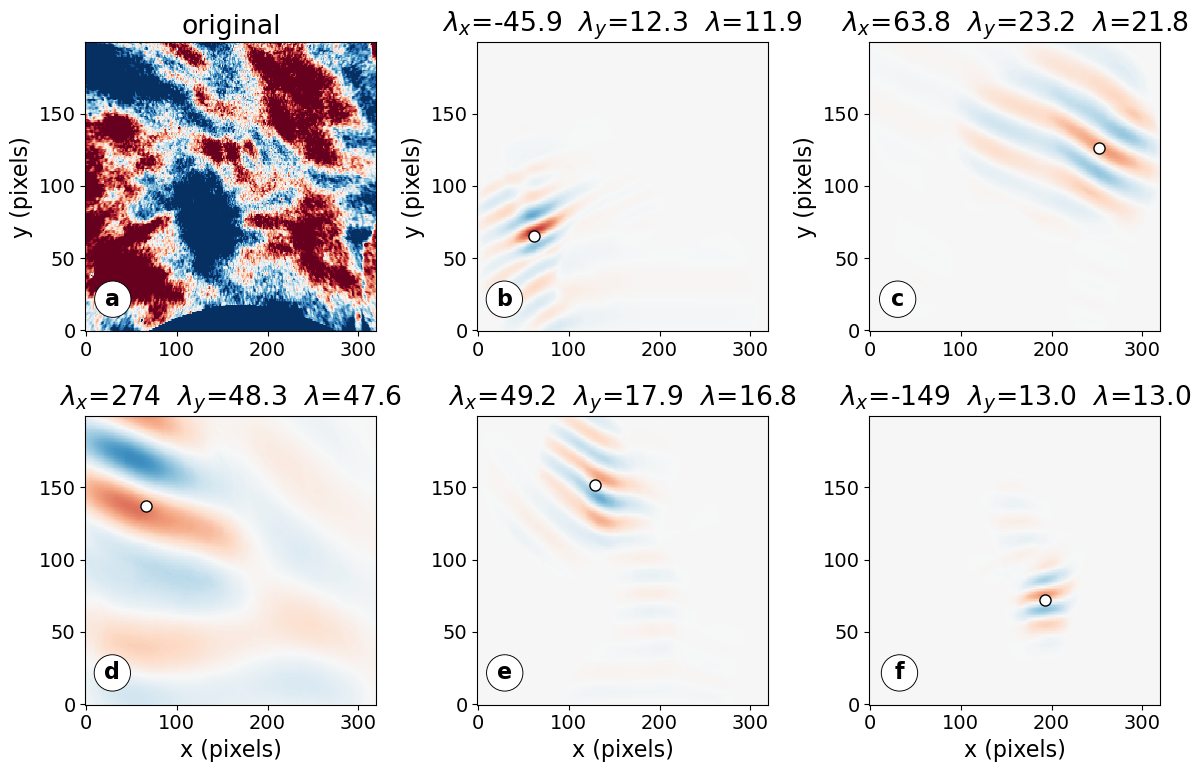

In [77]:
# example_decompose2d_from_tiff_rangefilter_top5.py
# Load a 16-bit TIFF, optionally mask values outside [6000, 10000] for stats/preview,
# fill masked values for CWT, run juwavelet 2D CWT, and plot:
#   (a) original
#   (b–f) top 5 waves by cluster amplitude (if available)

from __future__ import annotations
import string
from typing import Tuple, Optional, List

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\BandOH_caun0121.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = None
Y_SLICE: Optional[slice] = slice(0, 200)

# Range filter (remove everything <min or >max for stats/preview)
APPLY_RANGE_FILTER = True
RANGE_MIN = 6000.0
RANGE_MAX = 10000.0

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing
REMOVE_TREND = True        # subtract 2D plane
STANDARDIZE = True         # z-score to unit variance
GAUSS_BLUR_SIGMA = 0.0     # 0 disables, else e.g., 0.8

# Wavelet params
S0 = 8
DJ = 1/8
JS = 53
JT = 18
ASPECT = 1

# Pixel spacing (update if known)
DX = .623
DY = .623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win

def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)

def detrend_plane(Z: np.ndarray) -> np.ndarray:
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return Z - plane

def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))

def quicklook_pcolor(x1d: np.ndarray, y1d: np.ndarray, Z: np.ndarray, title: str, cmap="gray") -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()

def robust_stretch(Z: np.ndarray, p1=1, p2=99) -> np.ndarray:
    finite = np.isfinite(Z)
    if not np.any(finite):
        return Z
    v1, v2 = np.percentile(Z[finite], [p1, p2])
    return np.clip(Z, v1, v2)

def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out

def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)

    # Range filter: masked preview + stats
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, RANGE_MIN, RANGE_MAX)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan

        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"Min/Max: {np.nanmin(preview):.2f} / {np.nanmax(preview):.2f}")
            print(f"Mean/Std: {np.nanmean(preview):.2f} / {np.nanstd(preview):.2f}")
            p5, p50, p95 = np.nanpercentile(preview, [5, 50, 95])
            print(f"Percentiles 5/50/95: {p5:.2f} / {p50:.2f} / {p95:.2f}")
        else:
            print("Warning: no pixels within the specified range")

        quicklook_pcolor(
            x1d, y1d, robust_stretch(preview),
            f"TIFF masked to [{RANGE_MIN:.0f}, {RANGE_MAX:.0f}] (1–99% stretch)"
        )
    else:
        quicklook_pcolor(x1d, y1d, robust_stretch(raw), "TIFF raw (1–99% stretch)")

    # Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER and mask is not None else raw

    # Preprocess for CWT
    proc = filled.copy()
    if REMOVE_TREND:
        proc = detrend_plane(proc)
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        proc = (proc - m) / s if s > 0 else (proc - m)
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    quicklook_pcolor(x1d, y1d, proc, "Preprocessed for CWT")

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    # amps: sequence of amplitudes per cluster; idxs: list of (scale_idx, theta_idx, ...)
    # iwave: per-(scale,theta)-component label image
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.15)

    decomposition, period, theta = [cwt[k] for k in ("decomposition", "period", "theta")]
    orig = decomposition.copy()

    # Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # ---- PLOT: original + top 5 waves by amplitude ----
    # Arrange in 2x3 = 6 panels: (0) original, (1..5) top waves
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    axs = axs.flatten()

    opts_img = {"cmap": "RdBu_r", "vmin": -1, "vmax": 1, "rasterized": True}

    # (a) original
    axs[0].set_title("original")
    axs[0].pcolormesh(x1d, y1d, proc, **opts_img)

    # Determine top-K wave indices by amplitude
    K = 5
    if isinstance(amps, (list, tuple, np.ndarray)) and len(amps) > 0:
        amps = np.asarray(amps, dtype=float)
        order = np.argsort(amps)[::-1]  # descending
        top_idx_list: List[int] = [int(i) for i in order[:K] if i < len(idxs)]
    else:
        top_idx_list = []

    # For each top wave: reconstruct and display
    for k, wave_idx in enumerate(top_idx_list, start=1):
        ax = axs[k]
        # mask everything except this wave
        decomposition[:] = orig
        decomposition[iwave != wave_idx] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)

        # wavelength annotations (robust to richer idx tuple)
        s_idx, t_idx = idxs[wave_idx][:2]
        lamx = cwt["wavelength_x"][s_idx, t_idx]
        lamy = cwt["wavelength_y"][s_idx, t_idx]
        inv2 = 0.0
        if np.isfinite(lamx) and lamx != 0:
            inv2 += (1.0 / lamx) ** 2
        if np.isfinite(lamy) and lamy != 0:
            inv2 += (1.0 / lamy) ** 2
        lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

        ax.set_title(
            #f"{(wave_idx)}  "+ 
            rf"$\lambda_x$={_fmt(lamx)}  "
            + rf"$\lambda_y$={_fmt(lamy)}  "
            + rf"$\lambda$={_fmt(lam)}"
        )
        ax.pcolormesh(x1d, y1d, rec.T, **opts_img)

        # mark peak location of this component
        decomposition[:] = np.abs(decomposition)
        max_rc = np.unravel_index(
            decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
        )
        ax.plot(x1d[max_rc[0]], y1d[max_rc[1]], "o", color="w", mec="k", ms=8)

        print(f"Top wave {k} (idx={wave_idx}): amp={amps[wave_idx]:.3f}, "
              f"lamx={lamx:.2f}, lamy={lamy:.2f}, lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}")

    # If fewer than 5 waves, turn off unused panels
    for j in range(1 + len(top_idx_list), 6):
        axs[j].axis("off")
        axs[j].set_title("")

    # Labels for right column x, top row y
    for ax in (axs[3], axs[4], axs[5]):
        ax.set_xlabel("x (pixels)")
    for ax in (axs[0], axs[1], axs[2]):
        ax.set_ylabel("y (pixels)")

    # letter tags (a–f)
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs, string.ascii_lowercase):
        ax.text(0.12, 0.15, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="right", weight="bold")

    fig.tight_layout()
    plt.show()

# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()
